In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload and read the dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("netflix_titles.csv")

print(df)
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.describe())

Saving netflix_titles.csv to netflix_titles.csv
     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi

In [3]:
df["duration_num"] = pd.to_numeric(
    df["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

     show_id     type                      title         director  \
0         s1    Movie       Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show              Blood & Water              NaN   
2         s3  TV Show                  Ganglands  Julien Leclercq   
3         s4  TV Show      Jailbirds New Orleans              NaN   
4         s5  TV Show               Kota Factory              NaN   
...      ...      ...                        ...              ...   
8787   s8788    Movie  You Can’t Fight Christmas      Kenny Young   
8794   s8795    Movie                     اشتباك     Mohamed Diab   
8796   s8797  TV Show                 Yunus Emre              NaN   
8797   s8798  TV Show                  Zak Storm              NaN   
8803   s8804  TV Show                Zombie Dumb              NaN   

                                                   cast  \
0                                                   NaN   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban.

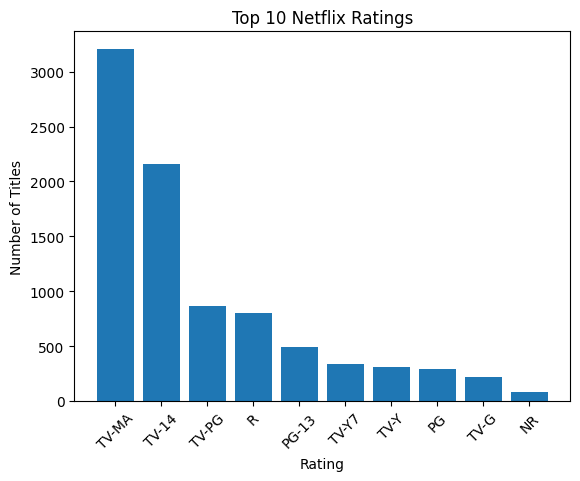

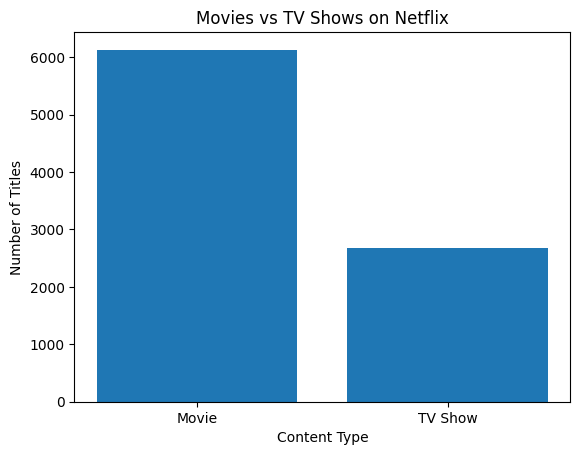

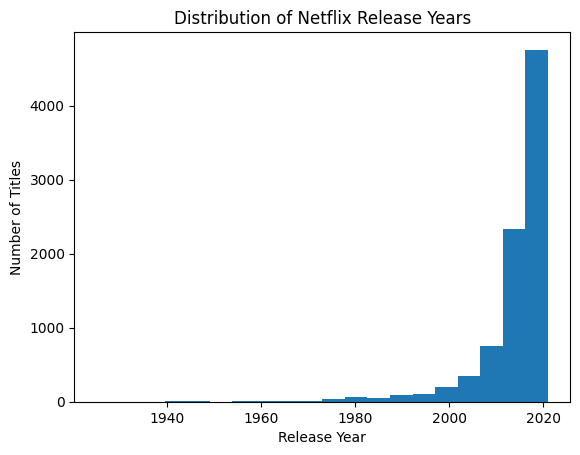

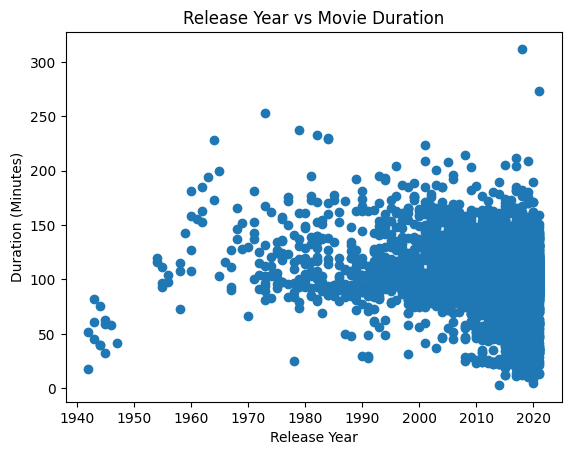

/tmp/ipykernel_811/2234186099.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([movies, tv_shows], labels=["Movie", "TV Show"])


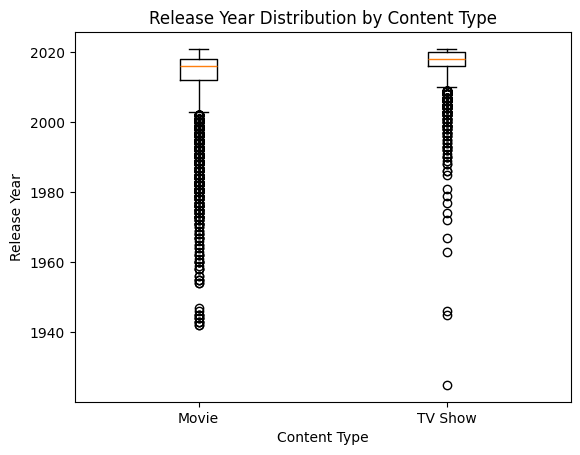

In [4]:
# Filtering
print(df[df["release_year"] > 2015])
print(df[df["type"] == "Movie"])

# Sorting
print(df.sort_values("release_year", ascending=False))
print(df.sort_values("title", ascending=True))

# Grouping
print(df.groupby("type")["release_year"].mean())
print(df.groupby("rating")["release_year"].mean().head(10))

# Statistical calculations
print("Mean Release Year:", df["release_year"].mean())
print("Median Release Year:", df["release_year"].median())
print("Minimum Release Year:", df["release_year"].min())
print("Maximum Release Year:", df["release_year"].max())
print("Standard Deviation:", df["release_year"].std())

# Correlation
print(df[["release_year", "duration_num"]].corr())
print("Correlation:", df["release_year"].corr(df["duration_num"]))

# Top 10 ratings
rating_count = df["rating"].value_counts().head(10)

plt.bar(rating_count.index, rating_count.values)
plt.title("Top 10 Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

# Movies vs TV Shows
type_count = df["type"].value_counts()

plt.bar(type_count.index, type_count.values)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

# Release Year Distribution
plt.hist(df["release_year"].dropna(), bins=20)
plt.title("Distribution of Netflix Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

# Release Year vs Movie Duration
movie_data = df[df["type"] == "Movie"].dropna(
    subset=["release_year", "duration_num"]
)

plt.scatter(movie_data["release_year"], movie_data["duration_num"])
plt.title("Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.show()

# Box Plot
movies = df[df["type"] == "Movie"]["release_year"].dropna()
tv_shows = df[df["type"] == "TV Show"]["release_year"].dropna()

plt.boxplot([movies, tv_shows], labels=["Movie", "TV Show"])
plt.title("Release Year Distribution by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Release Year")
plt.show()